#**SENTEMENT ANALYSIS WITH LSTM IN PYTORCH**

#**Workflow**

1. Import required Liaberies

2. Prepare Dataset()

3. Build a LSTM model

4. Pick loss function and optimizer

5. Build a training and evaluation loop

6. Visulize our model

7. Test our model on new sentece

#**1. Import required Liaberies**

In [1]:
!pip install torch==2.2.2 torchtext==0.17.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [87]:
import torch
import torch.nn as nn
import torch.optim
import datasets
import torchtext
import numpy as np
import collections
import matplotlib.pyplot as plt
import tqdm

In [88]:
print(torch.__version__)

2.2.2+cu121


# **2. Prepare Our Data**

In [186]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')

if HF_TOKEN:
    login(HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("HF_TOKEN not found in Colab secrets.")

Successfully logged in to Hugging Face!


## **2.1 Load Datasets**

In [187]:
train_data, test_data = datasets.load_dataset("imdb",
                                              split=["train", "test"])

In [188]:
train_data

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [189]:
test_data

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [190]:
train_data[0]["text"]

'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, ev

## **2.2 Tokanize our data**

In [191]:
tokenizer = torchtext.data.utils.get_tokenizer("basic_english")

In [192]:
def tokenize(example,tokenizer,max_length):
  tokens = tokenizer(example["text"])[:max_length]
  length = len(tokens)
  return {"tokens" : tokens,
          "length" : length
          }

In [193]:
max_length = 256
train_data = train_data.map(tokenize,
                            fn_kwargs={"tokenizer":tokenizer,
                                       "max_length":max_length}
                            )

test_data = test_data.map(tokenize,
                          fn_kwargs={"tokenizer": tokenizer,
                                     "max_length":max_length})

In [194]:
train_data

Dataset({
    features: ['text', 'label', 'tokens', 'length'],
    num_rows: 25000
})

##**2.3 Creating validation data**

In [195]:
test_size = 0.25
train_valid_data = train_data.train_test_split(test_size=test_size)

In [196]:
train_data=train_valid_data["train"]
valid_data=train_valid_data["test"]

In [197]:
train_valid_data

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'tokens', 'length'],
        num_rows: 18750
    })
    test: Dataset({
        features: ['text', 'label', 'tokens', 'length'],
        num_rows: 6250
    })
})

##**2.4 Creating Vocabalery**

In [198]:
min_freq = 5
special_tokens = ["<unk>", "<pad>"]

In [199]:
vocab = torchtext.vocab.build_vocab_from_iterator(train_data["tokens"],
                                                  min_freq=min_freq,
                                                  specials=special_tokens)

In [200]:
unk_index=vocab["<unk>"]
pad_index=vocab["<pad>"]

In [201]:
vocab.set_default_index(unk_index)

# **2.5 Numerize Data**

In [202]:
def numerize_example(example,vocab):
  ids = vocab.lookup_indices(example["tokens"])
  return {"ids":ids}

In [203]:
train_data = train_data.map(numerize_example,
                            fn_kwargs={"vocab":vocab})
valid_data = valid_data.map(numerize_example,
                            fn_kwargs={"vocab":vocab})
test_data = test_data.map(numerize_example,
                          fn_kwargs={"vocab":vocab})

Map:   0%|          | 0/18750 [00:00<?, ? examples/s]

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [204]:
train_data["ids"][:1]

[[293,
  75,
  356,
  138,
  40,
  684,
  15,
  14,
  167,
  9,
  28,
  327,
  51,
  243,
  45,
  5,
  18,
  3,
  11,
  196,
  45,
  48,
  170,
  242,
  120,
  47,
  971,
  530,
  6,
  897,
  20,
  67,
  161,
  23,
  1122,
  422,
  155,
  11,
  70,
  3,
  2,
  408,
  2434,
  30,
  44,
  849,
  870,
  15,
  2,
  64,
  10,
  600,
  2,
  12299,
  103,
  652,
  128,
  257,
  2,
  1043,
  3954,
  20,
  11,
  3,
  14,
  23,
  321,
  197,
  8,
  129,
  67,
  18,
  12,
  9,
  140,
  110,
  49,
  233,
  166,
  8,
  5,
  5214,
  129,
  2,
  23,
  723,
  493,
  5,
  2233,
  3649,
  737,
  2,
  1043,
  172,
  1402,
  7,
  3339,
  3,
  107,
  602,
  3,
  2,
  1028,
  18,
  300,
  10,
  71,
  350,
  19,
  41,
  0,
  242,
  43,
  129,
  78,
  59,
  74,
  172,
  14139,
  7,
  144,
  351,
  13,
  5,
  3479,
  85,
  126,
  1429,
  3,
  4386,
  11,
  196,
  15,
  183,
  853,
  30,
  17916,
  2,
  517,
  7,
  23,
  257,
  21,
  7684,
  3,
  14,
  10,
  58,
  589,
  3,
  2,
  1403,
  10,
  6763,
  2,
  517

##**2.6 Converting into tensors**

In [205]:
train_data = train_data.with_format(type="torch",
                                    columns=["ids", "label", "length"])
valid_data = valid_data.with_format(type="torch",
                                    columns=["ids", "label", "length"])
test_data = test_data.with_format(type="torch",
                                  columns=["ids", "label", "length"])

##**2.7 Creating data loader**

In [206]:
import torch
import torch.nn as nn

def get_collate(pad_index):
    def collate_fn(batch):
        batch_ids = [i["ids"] for i in batch]

        padded_ids = nn.utils.rnn.pad_sequence(
            batch_ids,
            padding_value=pad_index,
            batch_first=True
        )

        batch_length = [i["length"] for i in batch]
        batch_length = torch.stack(batch_length)

        batch_label = [i["label"] for i in batch]
        batch_label = torch.stack(batch_label)

        return {
            "ids": padded_ids,
            "length": batch_length,
            "label": batch_label
        }

    return collate_fn

In [207]:
from huggingface_hub import get_collection
def get_data_loader(dataset,batch_size,pad_index,shuffle=False):
  collate_fn = get_collate(pad_index)
  data_loader = torch.utils.data.DataLoader(
      dataset = dataset,
      batch_size = batch_size,
      collate_fn = collate_fn,
      shuffle = shuffle
  )
  return data_loader

In [208]:
batch_size = 512
train_data_loader=get_data_loader(train_data,batch_size,pad_index,shuffle=True)
valid_data_loader=get_data_loader(valid_data,batch_size,pad_index)
test_data_loader=get_data_loader(test_data,batch_size,pad_index)

#**3. Build LSTM Model**

In [209]:
len(vocab)

21618

In [210]:
len(train_data.unique("label"))

2

In [211]:
class LSTM(nn.Module):
  def __init__(self,vocab_size,embedding_dim,hidden_dim,n_layer,bidirectional,dropout_rate,pad_index,output_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size,embedding_dim,pad_index)

    self.lstm = nn.LSTM(embedding_dim, hidden_size = hidden_dim,num_layers = n_layer, bidirectional = bidirectional, dropout = dropout_rate, batch_first=True)

    self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

    self.dropout = nn.Dropout(dropout_rate)

  def forward(self, ids, length):
    # ids = [batch_size,seq_length]
    # length = [batch_size]
    embedded = self.dropout(self.embedding(ids))
    # embedded = [batch_size, seq_length, embedding_dim]
    packed_embedded = nn.utils.rnn.pack_padded_sequence(
        embedded, lengths=length, batch_first=True, enforce_sorted=False
        )
    packed_output, (hidden, cell) = self.lstm(packed_embedded)
    # hidden = [n_layers * direction, batch_size, hidden_dim]
    # cell = [n_layers * direction, batch_size, hidden_dim]
    output, output_length = nn.utils.rnn.pad_packed_sequence(packed_output)
    # output = [batch_size_seq_length, hidden_dim*directions]

    if self.lstm.bidirectional:
      hidden = self.dropout(torch.cat((hidden[-1], hidden[-2]), dim=-1))
      #hidden = [batch_size, hidden_dim*2]

    else:
      hidden = self.dropout(hidden[-1])
      # hidden=[batch_size, hidden_dim]

    prediction = self.fc(hidden)
    return prediction

In [212]:
vocab_size = len(vocab)
embedding_dim = 300
hidden_dim = 300
output_dim = len(train_data.unique("label"))
n_layer = 2
bidirectional = True  #forward and backward
dropout_rate = 0.5 #50%

In [213]:
model = LSTM(vocab_size,embedding_dim,hidden_dim,n_layer,bidirectional,dropout_rate,pad_index,output_dim)

In [214]:
model

LSTM(
  (embedding): Embedding(21618, 300, padding_idx=1)
  (lstm): LSTM(300, 300, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=600, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [215]:
model.state_dict()

OrderedDict([('embedding.weight',
              tensor([[-0.2392,  2.3017, -0.9489,  ..., -1.0131,  0.1760, -1.9616],
                      [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
                      [-0.8621,  0.2117, -1.3478,  ...,  0.4686,  2.6399, -1.5744],
                      ...,
                      [-0.3663,  1.6301,  0.8041,  ...,  0.3940,  1.1117, -1.6034],
                      [ 1.0686, -0.0078,  1.4125,  ..., -1.7661,  0.0492,  1.2710],
                      [ 0.5423, -1.9507, -0.2211,  ..., -1.6338,  1.9067,  1.0950]])),
             ('lstm.weight_ih_l0',
              tensor([[-0.0483,  0.0213,  0.0214,  ...,  0.0347,  0.0507, -0.0108],
                      [ 0.0214, -0.0496,  0.0149,  ...,  0.0207, -0.0029, -0.0372],
                      [ 0.0369,  0.0102,  0.0218,  ..., -0.0006,  0.0441,  0.0475],
                      ...,
                      [-0.0175,  0.0047, -0.0271,  ...,  0.0196, -0.0160, -0.0478],
                      [ 0.0161, -0

In [216]:
trainable_parameters = sum(i.numel() for i in model.parameters())

print(f"The model has {trainable_parameters:,} trainable parameters.")

The model has 10,096,202 trainable parameters.


*The model have **10M** trainable parameters*

**Weight initialization**

In [217]:
def initialize_weights(m):
  if isinstance(m,nn.Linear):
    nn.init.xavier_normal_(m.weight)
    nn.init.zeros_(m.bias)
  elif isinstance(m,nn.LSTM):
    for name,param in m.named_parameters():
      if "bias" in name:
        nn.init.zeros_(param)
      elif "weight" in  name:
        nn.init.orthogonal_(param)

#**4. Pick a Loss function and Optimoizer**

**Loss Function**

In [218]:
criterian = nn.CrossEntropyLoss()

**Optimier**

In [219]:
lr = 3e-4
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

**Device**

In [220]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [221]:
model = model.to(device)
criterion = criterian.to(device)

#**5. Build training and evaluation loop**

In [222]:
def train(dataloader, model, criterion, optimizer, device):
    model.train()
    epoch_losses = []
    epoch_accs = []
    for batch in tqdm.tqdm(dataloader, desc="training..."):
        ids = batch["ids"].to(device)
        length = batch["length"]
        label = batch["label"].to(device)
        prediction = model(ids, length)
        loss = criterion(prediction, label)
        accuracy = get_accuracy(prediction, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        epoch_accs.append(accuracy.item())
    return np.mean(epoch_losses), np.mean(epoch_accs)

In [223]:
def evaluate(dataloader, model, criterion, device):
    model.eval()
    epoch_losses = []
    epoch_accs = []
    with torch.no_grad():
        for batch in tqdm.tqdm(dataloader, desc="evaluating..."):
            ids = batch["ids"].to(device)
            length = batch["length"]
            label = batch["label"].to(device)
            prediction = model(ids, length)
            loss = criterion(prediction, label)
            accuracy = get_accuracy(prediction, label)
            epoch_losses.append(loss.item())
            epoch_accs.append(accuracy.item())
    return np.mean(epoch_losses), np.mean(epoch_accs)

In [224]:
def get_accuracy(prediction, label):
    batch_size, _ = prediction.shape
    predicted_classes = prediction.argmax(dim=-1)
    correct_predictions = predicted_classes.eq(label).sum()
    accuracy = correct_predictions / batch_size
    return accuracy

In [225]:
n_epochs = 10
best_valid_loss = float("inf")

metrics = collections.defaultdict(list)

for epoch in range(n_epochs):
    train_loss, train_acc = train(
        train_data_loader, model, criterion, optimizer, device
    )
    valid_loss, valid_acc = evaluate(valid_data_loader, model, criterion, device)
    metrics["train_losses"].append(train_loss)
    metrics["train_accs"].append(train_acc)
    metrics["valid_losses"].append(valid_loss)
    metrics["valid_accs"].append(valid_acc)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "lstm.pt")
    print(f"epoch: {epoch}")
    print(f"train_loss: {train_loss:.3f}, train_acc: {train_acc:.3f}")
    print(f"valid_loss: {valid_loss:.3f}, valid_acc: {valid_acc:.3f}")

evaluating...: 100%|██████████| 13/13 [00:04<00:00,  3.06it/s]


epoch: 0
train_loss: 0.687, train_acc: 0.540
valid_loss: 0.679, valid_acc: 0.563


evaluating...: 100%|██████████| 13/13 [00:03<00:00,  3.28it/s]


epoch: 1
train_loss: 0.651, train_acc: 0.615
valid_loss: 0.560, valid_acc: 0.710


evaluating...: 100%|██████████| 13/13 [00:04<00:00,  3.19it/s]


...

epoch: 7
train_loss: 0.416, train_acc: 0.808
valid_loss: 0.407, valid_acc: 0.836


evaluating...: 100%|██████████| 13/13 [00:04<00:00,  3.19it/s]


epoch: 8
train_loss: 0.384, train_acc: 0.827
valid_loss: 0.430, valid_acc: 0.835


evaluating...: 100%|██████████| 13/13 [00:04<00:00,  3.15it/s]

epoch: 9
train_loss: 0.388, train_acc: 0.828
valid_loss: 0.425, valid_acc: 0.830


#**6. Visulize model**

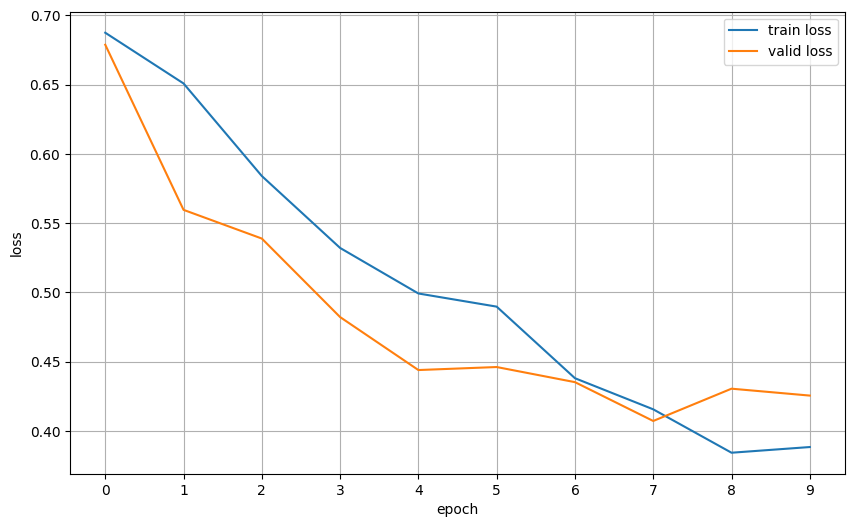

In [226]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_losses"], label="train loss")
ax.plot(metrics["valid_losses"], label="valid loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

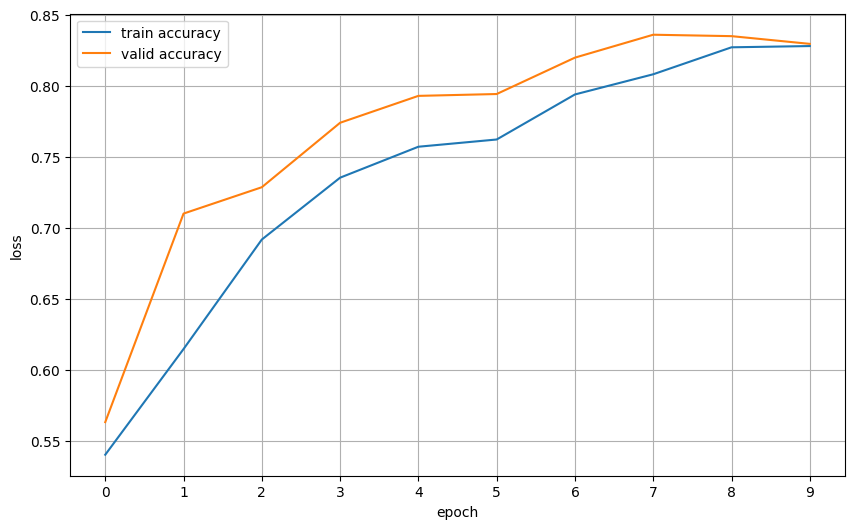

In [227]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_accs"], label="train accuracy")
ax.plot(metrics["valid_accs"], label="valid accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

#**7. Test model on new datapoint**

In [228]:
model.load_state_dict(torch.load("lstm.pt"))

test_loss, test_acc = evaluate(test_data_loader, model, criterion, device)

evaluating...: 100%|██████████| 49/49 [00:16<00:00,  2.94it/s]


In [229]:
print(f"test_loss: {test_loss:.3f}, test_acc: {test_acc:.3f}")

test_loss: 0.431, test_acc: 0.825


In [230]:
def predict_sentiment(text, model, tokenizer, vocab, device):
    tokens = tokenizer(text)
    ids = vocab.lookup_indices(tokens)
    length = torch.LongTensor([len(ids)])
    tensor = torch.LongTensor(ids).unsqueeze(dim=0).to(device)
    prediction = model(tensor, length).squeeze(dim=0)
    probability = torch.softmax(prediction, dim=-1)
    predicted_class = prediction.argmax(dim=-1).item()
    predicted_probability = probability[predicted_class].item()
    return predicted_class, predicted_probability

In [231]:
text = "This film is terrible!"

predict_sentiment(text, model, tokenizer, vocab, device)

(0, 0.5958157181739807)

In [232]:
text = "This film is great!"

predict_sentiment(text, model, tokenizer, vocab, device)

(1, 0.9371960163116455)

In [233]:
text = "This film is not terrible, it's great!"

predict_sentiment(text, model, tokenizer, vocab, device)

(1, 0.7861627340316772)

In [240]:
text = "not recommended"

predict_sentiment(text, model, tokenizer, vocab, device)

(0, 0.5167971253395081)